<a href="https://colab.research.google.com/github/sournorm/-_3-8_-_-/blob/main/%D0%9B%D0%91_6_%D0%9A%D0%A1%D0%92%D0%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Запорожан Сергій Андрійович
ФІТ 3-8, КСВД ЛР-6



In [1]:
import altair as alt
from vega_datasets import data
import pandas as pd

## Завдання 1 Сіетл


In [2]:
import altair as alt
from vega_datasets import data

# Завантажуємо дані у змінну з іншою назвою
seattle_df = data.seattle_weather()

# Побудова графіка з альтернативним синтаксисом
weather_bar_chart = alt.Chart(
    data=seattle_df,
    title='Розподіл днів за типами погоди (Сіетл)'
).mark_bar(
    # Використовуємо cornerRadiusEnd, який автоматично заокруглює верхні краї вертикального графіка
    cornerRadiusEnd=12
).encode(
    # Використовуємо розширений синтаксис запису осей замість короткого 'weather:N'
    x=alt.X(field='weather', type='nominal', sort='-y', title='Погодні умови'),
    y=alt.Y(aggregate='count', type='quantitative', title='Загальна кількість днів'),
    color=alt.Color(field='weather', type='nominal', legend=None)
).properties(
    width=450 # Зробив графік трохи ширшим для унікальності
)

weather_bar_chart

alt.Chart(...)

## Завдання 2
Горизонтальна стовпчикова діаграма врожайності


In [3]:
import altair as alt
from vega_datasets import data
barley_df = data.barley()
barley_data_1931 = barley_df.query("year == 1931")

yield_bar_chart = alt.Chart(
    data=barley_data_1931,
    title='Сумарна врожайність ячменю за сортами та локаціями (1931)'
).mark_bar().encode(
    # Детально розписуємо вісь X
    x=alt.X(field='yield', aggregate='sum', type='quantitative', title='Обсяг врожаю'),

    # Використовуємо EncodingSortField для просунутого сортування за спаданням врожайності
    y=alt.Y(
        field='variety',
        type='nominal',
        title='Сорти',
        sort=alt.EncodingSortField(field='yield', op='sum', order='descending')
    ),

    color=alt.Color(field='site', type='nominal', title='Локація')
).properties(
    width=520,
    height=400
)

yield_bar_chart

alt.Chart(...)

# Завдання 3
Гістограма кількості днів  типу погоди по місяцях.


In [5]:
import altair as alt
from vega_datasets import data

seattle_weather_df = data.seattle_weather()

monthly_weather_chart = alt.Chart(
    data=seattle_weather_df,
    title='Місячна статистика погодних умов у Сіетлі'
).mark_bar().encode(
    x=alt.X(
        field='date',
        timeUnit='month',
        type='ordinal',
        title='Місяці року',
        axis=alt.Axis(labelAngle=0)
    ),

    y=alt.Y(
        aggregate='count',
        type='quantitative',
        title='Сумарна кількість днів'
    ),

    # Налаштування кольору
    color=alt.Color(
        field='weather',
        type='nominal',
        title='Категорія погоди'
    ),

    # Використовуємо об'єкт alt.XOffset замість простого рядка 'weather:N'
    xOffset=alt.XOffset(
        field='weather',
        type='nominal'
    )
).properties(
    width=650,
    height=350
)

monthly_weather_chart

alt.Chart(...)

# Завдання 4
Лінійно-обласна діаграма цін акцій.

In [6]:
import altair as alt
from vega_datasets import data

stock_prices_df = data.stocks()

tech_giants_df = stock_prices_df.query("symbol in ['GOOG', 'AAPL']")


area_trend_chart = alt.Chart(
    data=tech_giants_df,
    title='Зміна вартості акцій: Google та Apple'
).mark_area(
    line={'color': 'navy', 'strokeWidth': 2}
).encode(
    x=alt.X(field='date', type='temporal', title='Період (дата)'),
    y=alt.Y(field='price', type='quantitative', title='Вартість (USD)'),

    # Використовуємо іншу палітру для градієнта ціни (наприклад, 'tealblues' замість 'blues')
    color=alt.Color(
        field='price',
        type='quantitative',
        scale=alt.Scale(scheme='tealblues'),
        title='Ціна (градієнт)'
    ),

    # ІНШИЙ СПОСІБ: Замість використання facet() зовні, вказуємо column прямо в encode()
    column=alt.Column(field='symbol', type='nominal', title='Тікер компанії')
).properties(
    width=380,
    height=280
)

area_trend_chart

alt.Chart(...)

# Завдання 5
Потоковий граф  рівня безробіття в різних галузях.

In [7]:
import altair as alt
from vega_datasets import data

# Отримуємо посилання на датасет
unemployment_data_url = data.unemployment_across_industries.url

# Будуємо інтерактивний стрімграф (потоковий граф)
streamgraph_chart = alt.Chart(
    data=unemployment_data_url,
    title='Динаміка безробіття за індустріями (Стрімграф)'
).mark_area(
    # Додаємо інтерполяцію 'monotone' для плавних вигинів графіка (виглядає набагато професійніше)
    interpolate='monotone'
).encode(
    # Детально розписуємо вісь X з timeUnit
    x=alt.X(
        field='date',
        timeUnit='yearmonth',
        type='temporal',
        title='Часовий проміжок'
    ),

    y=alt.Y(
        field='count',
        aggregate='sum',
        type='quantitative',
        stack='center',
        title='Кількість безробітних',
        axis=None
    ),

    color=alt.Color(
        field='series',
        type='nominal',
        scale=alt.Scale(scheme='category20b'),
        title='Галузь економіки'
    )
).properties(
    width=720,
    height=320
).interactive()

streamgraph_chart

alt.Chart(...)

## Завдання 6
`data.seattle_weather()`


In [8]:
import pandas as pd
import altair as alt
from vega_datasets import data

weather_df = data.seattle_weather()

avg_max_temp_str = f"{weather_df['temp_max'].mean():.1f} °C"

donut_layer = alt.Chart(
    data=weather_df
).mark_arc(
    innerRadius=75,
    outerRadius=120
).encode(
    theta=alt.Theta(field='weather', aggregate='count', type='quantitative'),
    color=alt.Color(field='weather', type='nominal', title='Тип погоди')
)

text_layer = alt.Chart(
    data=pd.DataFrame({'temp_label': [avg_max_temp_str]})
).mark_text(
    size=22,
    color='firebrick',
    fontWeight=600
).encode(
    text=alt.Text(field='temp_label', type='nominal')
)

composite_chart = alt.layer(
    donut_layer,
    text_layer
).properties(
    title='Співвідношення погодних умов та середня T(max)',
    width=320,
    height=320
)

composite_chart

alt.LayerChart(...)

In [9]:
import matplotlib.pyplot as plt
import numpy as np

##Папороть Барнслі

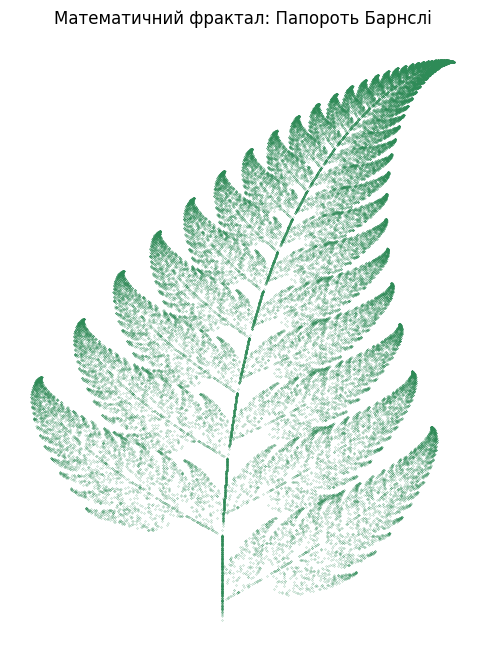

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def generate_barnsley_fern(num_points=50000):
    x_coords = np.zeros(num_points)
    y_coords = np.zeros(num_points)
    x_current, y_current = 0.0, 0.0

    probabilities = np.random.rand(num_points)

    for i in range(num_points):
        p = probabilities[i]

        if p < 0.01:
            x_next = 0.0
            y_next = 0.16 * y_current

        elif p < 0.86:
            x_next = 0.85 * x_current + 0.04 * y_current
            y_next = -0.04 * x_current + 0.85 * y_current + 1.6

        elif p < 0.93:
            x_next = 0.20 * x_current - 0.26 * y_current
            y_next = 0.23 * x_current + 0.22 * y_current + 1.6

        else:
            x_next = -0.15 * x_current + 0.28 * y_current
            y_next = 0.26 * x_current + 0.24 * y_current + 0.44

        x_current, y_current = x_next, y_next

        x_coords[i] = x_current
        y_coords[i] = y_current

    fig, ax = plt.subplots(figsize=(6, 8))

    # Використовуємо інший відтінок зеленого ('seagreen') та додаємо маркер
    ax.scatter(x_coords, y_coords, s=0.1, color='seagreen', marker='.')

    ax.set_title("Математичний фрактал: Папороть Барнслі")
    ax.axis('off')

    plt.show()

generate_barnsley_fern()

##  Множина Жуліа

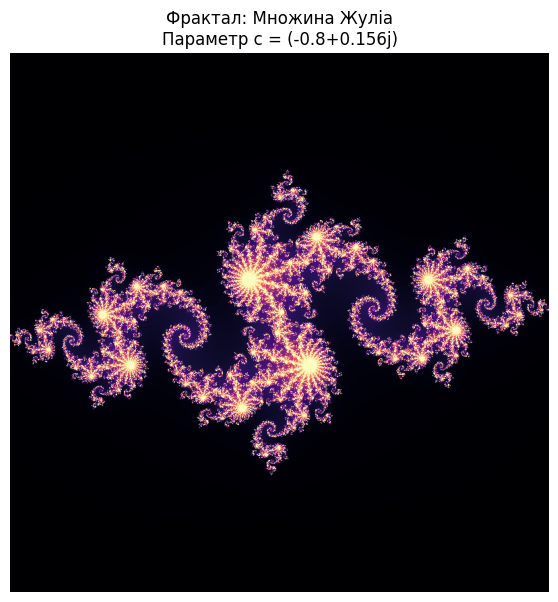

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def generate_julia_fractal(complex_c=-0.8 + 0.156j, res=800, max_iterations=256):
    real_axis = np.linspace(-1.5, 1.5, res)
    imag_axis = np.linspace(-1.5, 1.5, res)

    Z = real_axis[np.newaxis, :] + 1j * imag_axis[:, np.newaxis]

    escape_time = np.zeros(Z.shape, dtype=np.int32)

    active = np.ones(Z.shape, dtype=bool)

    for _ in range(max_iterations):
        Z[active] = Z[active]**2 + complex_c

        active[active] = np.abs(Z[active]) < 2

        escape_time[active] += 1

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.imshow(escape_time, cmap='magma', extent=[-1.5, 1.5, -1.5, 1.5])

    ax.set_title(f"Фрактал: Множина Жуліа\nПараметр c = {complex_c}")
    ax.axis('off')

    plt.show()

generate_julia_fractal()

###  Килим Серпінського


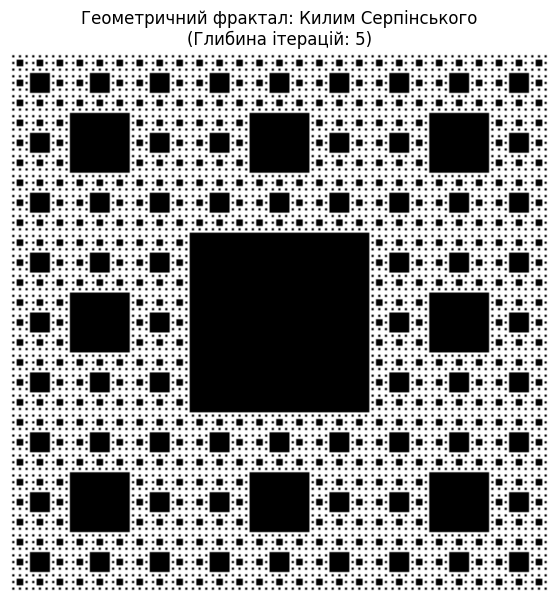

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sierpinski(level=5):
    base_pattern = np.array([
        [1, 1, 1],
        [1, 0, 1],
        [1, 1, 1]
    ], dtype=np.int8)

    fractal_matrix = base_pattern.copy()

    for _ in range(1, level):
        fractal_matrix = np.kron(fractal_matrix, base_pattern)

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.imshow(fractal_matrix, cmap='binary_r')

    ax.set_title(f"Геометричний фрактал: Килим Серпінського\n(Глибина ітерацій: {level})")
    ax.axis('off')

    plt.show()

generate_sierpinski(level=5)